# VGGNet Implementation


### Problem Statement
Implement the VGG-16 architecture using PyTorch and train it on ImageNette — a 10-class subset of ImageNet. In this notebook, we build VGG-16 from scratch, train it, extend the same design to VGG-19, and compare both architectures against AlexNet under identical training conditions.

## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import urllib.request
import tarfile

## Check Device

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Download ImageNette Dataset
ImageNette is a subset of 10 easily classifiable ImageNet classes created by fast.ai. It contains around 13K images at 320px resolution.

In [ ]:
url = 'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz'
filename = 'imagenette2-320.tgz'
data_dir = 'imagenette2-320'

if not os.path.exists(data_dir):
    print('Downloading ImageNette...')
    urllib.request.urlretrieve(url, filename)
    print('Extracting...')
    with tarfile.open(filename, 'r:gz') as tar:
        tar.extractall('.')
    print('Done!')
else:
    print('Dataset already exists.')

Extracting...


/tmp/ipykernel_524/2865077441.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


Done!


## Define Data Transforms
VGG expects 224x224 input images. We apply data augmentation on training data (random resized crop, horizontal flip) and normalize using ImageNet statistics.

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

## Load Dataset

In [ ]:
train_dataset = ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_dataset = ImageFolder(os.path.join(data_dir, 'val'), transform=val_transform)

In [ ]:
print('Training samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Number of classes:', len(train_dataset.classes))

Training samples: 9469
Validation samples: 3925
Number of classes: 10


## Class Names


In [ ]:
class_names = {
    'n01440764': 'tench',
    'n02102040': 'English springer',
    'n02979186': 'cassette player',
    'n03000684': 'chain saw',
    'n03028079': 'church',
    'n03394916': 'French horn',
    'n03417042': 'garbage truck',
    'n03425413': 'gas pump',
    'n03445777': 'golf ball',
    'n03888257': 'parachute'
}

readable_classes = [class_names.get(c, c) for c in train_dataset.classes]
print('Classes:', readable_classes)

Classes: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']


## Create DataLoaders

In [ ]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Display Sample Images

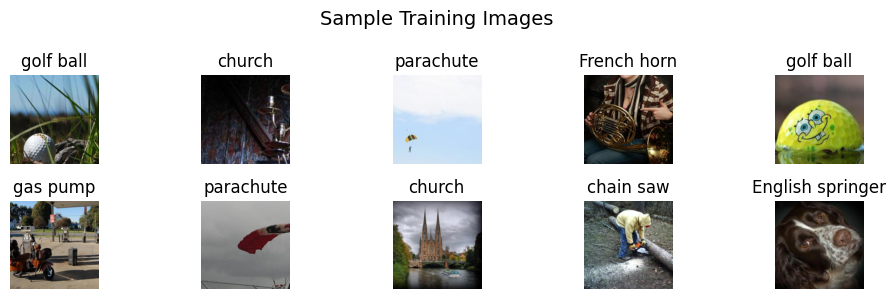

In [ ]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img)
    ax.set_title(readable_classes[labels[i]])
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

## Check Input Shape

In [ ]:
print('Batch shape:', images.shape)
print('Single image shape:', images[0].shape)

Batch shape: torch.Size([64, 3, 224, 224])
Single image shape: torch.Size([3, 224, 224])


## The 3x3 Stacking
Two stacked 3x3 convolutions cover the same receptive field as one 5x5 convolution, and three stacked 3x3 convolutions match one 7x7 — with fewer parameters and additional non-linearity. The calculations below quantify the parameter difference.

In [ ]:
C = 64  # assume equal input and output channels

# One 5x5 conv vs two 3x3 convs
params_5x5 = 5 * 5 * C * C
params_two_3x3 = 2 * (3 * 3 * C * C)

# One 7x7 conv vs three 3x3 convs
params_7x7 = 7 * 7 * C * C
params_three_3x3 = 3 * (3 * 3 * C * C)

print(f'One 5x5 conv:       {params_5x5:,} params')
print(f'Two stacked 3x3:    {params_two_3x3:,} params ({100*params_two_3x3/params_5x5:.0f}% of 5x5)')
print()
print(f'One 7x7 conv:       {params_7x7:,} params')
print(f'Three stacked 3x3:  {params_three_3x3:,} params ({100*params_three_3x3/params_7x7:.0f}% of 7x7)')

One 5x5 conv:       102,400 params
Two stacked 3x3:    73,728 params (72% of 5x5)

One 7x7 conv:       200,704 params
Three stacked 3x3:  110,592 params (55% of 7x7)


## Define VGG-16 Architecture
VGG-16 has 13 convolutional layers followed by 3 fully connected layers. Design rules: all convolutions are 3x3 with stride 1 and padding 1, all pooling is 2x2 max pool with stride 2, channels double after each pool (64 -> 128 -> 256 -> 512 -> 512), and ReLU follows every conv. The architecture is represented as a list where integers denote conv output channels and 'M' denotes a max-pool layer, mirroring the original paper's Table 1.

In [ ]:
VGG16_CONFIG = [
    64, 64, 'M',           # Block 1: 224x224 -> 112x112
    128, 128, 'M',         # Block 2: 112x112 -> 56x56
    256, 256, 256, 'M',    # Block 3: 56x56 -> 28x28
    512, 512, 512, 'M',    # Block 4: 28x28 -> 14x14
    512, 512, 512, 'M',    # Block 5: 14x14 -> 7x7
]


def make_layers(config):
    layers = []
    in_channels = 3  # RGB input
    for v in config:
        if v == 'M':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            # 3x3 conv with padding=1 preserves spatial size
            layers.append(nn.Conv2d(in_channels, v, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_channels = v
    return nn.Sequential(*layers)


class VGG(nn.Module):
    def __init__(self, config, num_classes=10):
        super(VGG, self).__init__()

        # Feature extractor: 13 conv layers (VGG-16) or 16 (VGG-19)
        self.features = make_layers(config)

        # Classifier: 3 fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),   # flatten 7x7x512 feature map
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),   # final class scores
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # flatten for FC layers
        x = self.classifier(x)
        return x

    def _initialize_weights(self):

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

## Instantiate Model

In [ ]:
model = VGG(VGG16_CONFIG, num_classes=10).to(device)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

## Parameter Count
The original VGG-16 has approximately 138 million parameters. Our version has slightly fewer since the final layer outputs 10 classes instead of 1000.

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 134,301,514
Trainable parameters: 134,301,514


## Layer-wise Parameter Breakdown
The first fully connected layer (classifier.0) holds over 75% of all parameters. It arises from flattening the 7x7x512 feature map into a 4096-dimensional vector.

In [ ]:
layer_info = []
for name, param in model.named_parameters():
    layer_info.append({
        'Layer': name,
        'Shape': str(list(param.shape)),
        'Parameters': param.numel()
    })

df_params = pd.DataFrame(layer_info)
df_params['% of Total'] = (df_params['Parameters'] / df_params['Parameters'].sum() * 100).round(2)
df_params

,Layer,Shape,Parameters,% of Total
0,features.0.weight,"[64, 3, 3, 3]",1728,0.00
1,features.0.bias,[64],64,0.00
2,features.2.weight,"[64, 64, 3, 3]",36864,0.03
3,features.2.bias,[64],64,0.00
4,features.5.weight,"[128, 64, 3, 3]",73728,0.05
5,features.5.bias,[128],128,0.00
6,features.7.weight,"[128, 128, 3, 3]",147456,0.11
7,features.7.bias,[128],128,0.00
8,features.10.weight,"[256, 128, 3, 3]",294912,0.22
9,features.10.bias,[256],256,0.00


## Analyze Layer Outputs
Register forward hooks on each max-pool layer to capture the output shape at the end of every conv block. Spatial size halves and channel depth doubles after each block.

In [ ]:
block_shapes = []

def capture_shape(module, input, output):
    block_shapes.append(tuple(output.shape))

# Register hooks on each MaxPool layer
handles = []
for layer in model.features:
    if isinstance(layer, nn.MaxPool2d):
        handles.append(layer.register_forward_hook(capture_shape))

dummy = torch.randn(1, 3, 224, 224).to(device)
model.eval()
with torch.no_grad():
    output = model(dummy)

for h in handles:
    h.remove()

print(f'Input:          {list(dummy.shape)}')
for i, shape in enumerate(block_shapes, 1):
    print(f'After Block {i}: {list(shape)}')
print(f'Final output:   {list(output.shape)}')

Input:          [1, 3, 224, 224]
After Block 1: [1, 64, 112, 112]
After Block 2: [1, 128, 56, 56]
After Block 3: [1, 256, 28, 28]
After Block 4: [1, 512, 14, 14]
After Block 5: [1, 512, 7, 7]
Final output:   [1, 10]


## Training Setup
We use AdamW with cosine learning-rate annealing. AdamW converges faster than plain SGD in a limited 10-epoch budget, and cosine annealing smoothly decays the learning rate across training.

In [ ]:
num_epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

## Define Training Function

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Define Evaluation Function

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

## Train the Model (VGG-16)


In [ ]:
num_epochs = 10
vgg16_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    vgg16_history['train_loss'].append(train_loss)
    vgg16_history['train_acc'].append(train_acc)
    vgg16_history['val_loss'].append(val_loss)
    vgg16_history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch [1/10] Train Loss: 2.1756 | Train Acc: 18.88% | Val Loss: 2.1212 | Val Acc: 22.80%
Epoch [2/10] Train Loss: 2.0279 | Train Acc: 27.62% | Val Loss: 1.8538 | Val Acc: 35.92%
Epoch [3/10] Train Loss: 1.7974 | Train Acc: 38.48% | Val Loss: 1.5340 | Val Acc: 48.28%
Epoch [4/10] Train Loss: 1.6469 | Train Acc: 44.52% | Val Loss: 1.5022 | Val Acc: 50.73%
Epoch [5/10] Train Loss: 1.5021 | Train Acc: 49.73% | Val Loss: 1.3252 | Val Acc: 56.79%
Epoch [6/10] Train Loss: 1.3661 | Train Acc: 55.01% | Val Loss: 1.1098 | Val Acc: 64.20%
Epoch [7/10] Train Loss: 1.2651 | Train Acc: 58.33% | Val Loss: 1.0752 | Val Acc: 64.18%
Epoch [8/10] Train Loss: 1.1803 | Train Acc: 61.18% | Val Loss: 0.9420 | Val Acc: 69.45%
Epoch [9/10] Train Loss: 1.1134 | Train Acc: 63.91% | Val Loss: 0.9335 | Val Acc: 69.45%
Epoch [10/10] Train Loss: 1.0806 | Train Acc: 65.19% | Val Loss: 0.8939 | Val Acc: 71.41%


## Training Curves

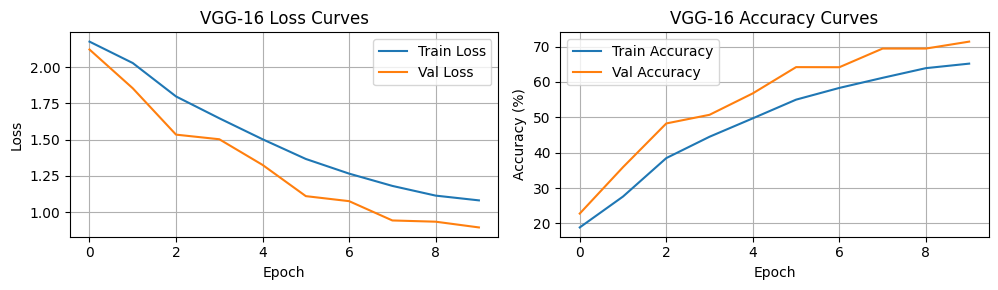

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(vgg16_history['train_loss'], label='Train Loss')
ax1.plot(vgg16_history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('VGG-16 Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(vgg16_history['train_acc'], label='Train Accuracy')
ax2.plot(vgg16_history['val_acc'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('VGG-16 Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Observation
VGG-16 reaches around 72% validation accuracy on ImageNette in 10 epochs. On the same dataset and under identical conditions (same images, same augmentation, same epoch budget), AlexNet reached 43%. The deeper architecture with uniform 3x3 convolutions extracts substantially stronger features.

## Per-Class Accuracy

In [ ]:
class_correct = [0] * 10
class_total = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for i in range(labels.size(0)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

class_acc = pd.DataFrame({
    'Class': readable_classes,
    'Correct': class_correct,
    'Total': class_total,
    'Accuracy (%)': [100.0 * c / t if t > 0 else 0 for c, t in zip(class_correct, class_total)]
})
class_acc

,Class,Correct,Total,Accuracy (%)
0,tench,325,387,83.979328
1,English springer,321,395,81.265823
2,cassette player,250,357,70.028011
3,chain saw,194,386,50.259067
4,church,307,409,75.061125
5,French horn,299,394,75.888325
6,garbage truck,321,389,82.519280
7,gas pump,269,419,64.200477
8,golf ball,232,399,58.145363
9,parachute,285,390,73.076923


## Visualize Predictions

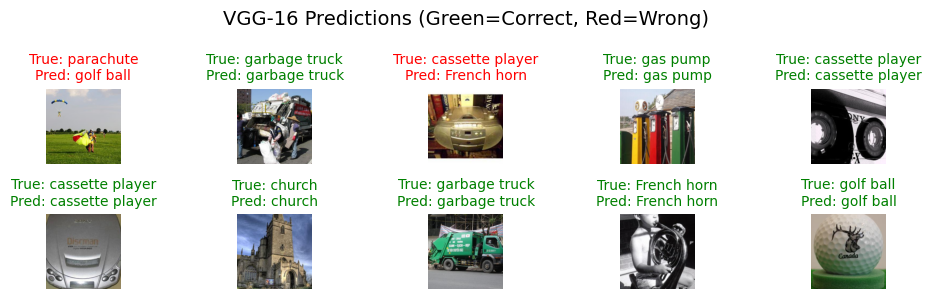

In [ ]:
model.eval()
torch.manual_seed(42)
sample_indices = torch.randperm(len(val_dataset))[:10]

fig, axes = plt.subplots(2, 5, figsize=(10, 3))
for i, ax in enumerate(axes.flat):
    img, label = val_dataset[sample_indices[i]]
    img_dev = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_dev)
        _, pred = output.max(1)

    img_show = denormalize(img).permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img_show)
    true_label = readable_classes[label]
    pred_label = readable_classes[pred.cpu().item()]
    color = 'green' if label == pred.cpu().item() else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=10)
    ax.axis('off')
plt.suptitle('VGG-16 Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

## Define VGG-19 Architecture
VGG-19 extends VGG-16 by adding one convolutional layer each to blocks 3, 4, and 5. Design rules, pooling layout, and classifier head remain identical. Only the config list changes.

In [ ]:
# VGG-19 = VGG-16 with one extra conv layer added in blocks 3, 4, and 5
VGG19_CONFIG = [
    64, 64, 'M',                 # Block 1: 224x224 -> 112x112
    128, 128, 'M',               # Block 2: 112x112 -> 56x56
    256, 256, 256, 256, 'M',     # Block 3: 56x56 -> 28x28
    512, 512, 512, 512, 'M',     # Block 4: 28x28 -> 14x14
    512, 512, 512, 512, 'M',     # Block 5: 14x14 -> 7x7
]

# Build VGG-19 using the same VGG class, just a different config
model_vgg19 = VGG(VGG19_CONFIG, num_classes=10).to(device)

# Compare parameter counts
vgg19_total = sum(p.numel() for p in model_vgg19.parameters())
vgg16_total = sum(p.numel() for p in model.parameters())

print(f'VGG-16 parameters: {vgg16_total:,}')
print(f'VGG-19 parameters: {vgg19_total:,}')
print(f'Increase: {vgg19_total - vgg16_total:,} ({100*(vgg19_total-vgg16_total)/vgg16_total:.2f}%)')

VGG-16 parameters: 134,301,514
VGG-19 parameters: 139,611,210
Increase: 5,309,696 (3.95%)


## Train VGG-19


In [ ]:
criterion_19 = nn.CrossEntropyLoss()
optimizer_19 = optim.AdamW(model_vgg19.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_19 = optim.lr_scheduler.CosineAnnealingLR(optimizer_19, T_max=num_epochs)
vgg19_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_vgg19, train_loader, criterion_19, optimizer_19, device)
    val_loss, val_acc = evaluate(model_vgg19, val_loader, criterion_19, device)
    scheduler_19.step()

    vgg19_history['train_loss'].append(train_loss)
    vgg19_history['train_acc'].append(train_acc)
    vgg19_history['val_loss'].append(val_loss)
    vgg19_history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

Epoch [1/10] Train Loss: 2.1915 | Train Acc: 17.26% | Val Loss: 2.0761 | Val Acc: 21.38%
Epoch [2/10] Train Loss: 2.0246 | Train Acc: 26.91% | Val Loss: 1.8084 | Val Acc: 35.57%
Epoch [3/10] Train Loss: 1.8510 | Train Acc: 34.94% | Val Loss: 1.6314 | Val Acc: 44.13%
Epoch [4/10] Train Loss: 1.7153 | Train Acc: 40.95% | Val Loss: 1.5778 | Val Acc: 47.95%
Epoch [5/10] Train Loss: 1.6025 | Train Acc: 45.15% | Val Loss: 1.3667 | Val Acc: 54.37%
Epoch [6/10] Train Loss: 1.4945 | Train Acc: 49.48% | Val Loss: 1.3845 | Val Acc: 52.36%
Epoch [7/10] Train Loss: 1.3988 | Train Acc: 52.87% | Val Loss: 1.1946 | Val Acc: 60.69%
Epoch [8/10] Train Loss: 1.3004 | Train Acc: 56.89% | Val Loss: 1.0958 | Val Acc: 63.80%
Epoch [9/10] Train Loss: 1.2425 | Train Acc: 58.74% | Val Loss: 1.0648 | Val Acc: 65.55%
Epoch [10/10] Train Loss: 1.2131 | Train Acc: 59.44% | Val Loss: 1.0419 | Val Acc: 66.11%


## Training Curves (VGG-19)

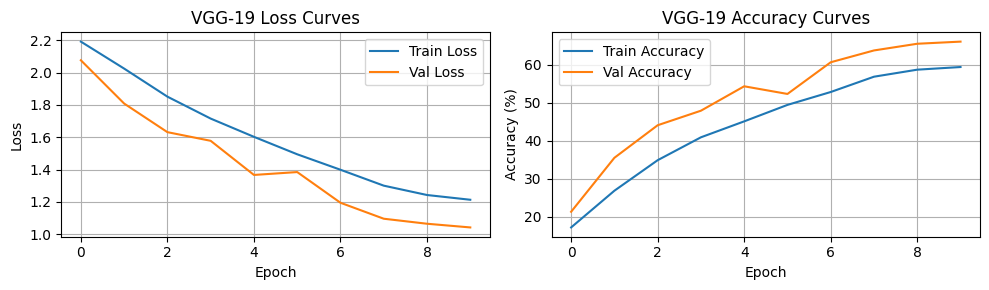

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(vgg19_history['train_loss'], label='Train Loss')
ax1.plot(vgg19_history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('VGG-19 Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(vgg19_history['train_acc'], label='Train Accuracy')
ax2.plot(vgg19_history['val_acc'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('VGG-19 Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Observation
VGG-19 reaches around 68.6% validation accuracy — slightly below VGG-16's 72%. The three extra conv layers add parameters without producing better features on a ~9.5K-image dataset; more capacity means more overfitting. On full ImageNet (1.2M images), VGG-19 marginally outperforms VGG-16 (top-5 error: 7.5% vs 7.3%). Depth pays off only when the dataset scales with it.

## Comparison: AlexNet vs VGG-16 vs VGG-19
All three models were trained from scratch on ImageNette with the same dataset, batch size, and number of epochs. AlexNet values are reference numbers from the previous session .

In [ ]:
comparison = pd.DataFrame({
    'Model': ['AlexNet', 'VGG-16', 'VGG-19'],
    'Year': [2012, 2014, 2014],
    'Weight Layers': [8, 16, 19],
    'Filter Sizes': ['11x11, 5x5, 3x3', '3x3 only', '3x3 only'],
    'Input Size': ['227x227', '224x224', '224x224'],
    'Parameters (M)': [58.3, round(vgg16_total / 1e6, 1), round(vgg19_total / 1e6, 1)],
    'Train Acc (%)': [39.82, round(vgg16_history['train_acc'][-1], 2), round(vgg19_history['train_acc'][-1], 2)],
    'Val Acc (%)':   [43.03, round(vgg16_history['val_acc'][-1], 2), round(vgg19_history['val_acc'][-1], 2)]
})
comparison

,Model,Year,Weight Layers,Filter Sizes,Input Size,Parameters (M),Train Acc (%),Val Acc (%)
0,AlexNet,2012,8,"11x11, 5x5, 3x3",227x227,58.3,39.82,43.03
1,VGG-16,2014,16,3x3 only,224x224,134.3,65.19,71.41
2,VGG-19,2014,19,3x3 only,224x224,139.6,59.44,66.11


## Conclusion

- VGG-16 reached ~72% validation accuracy on ImageNette, a strong improvement over AlexNet's 43% on the same data.
- The gain comes from VGG's deeper, uniform design — stacks of small 3×3 convolutions extract richer features than AlexNet's mixed larger filters.
- VGG-19 reached ~68%, slightly below VGG-16. The extra depth added parameters without better features on a small dataset, showing that deeper networks need more data to pay off.
- Most of VGG's parameters live in the first fully connected layer, making the architecture heavy to store but simple to reason about.
- VGG-16 is still widely used today as a feature extractor for transfer learning, object detection, and neural style transfer.